SMART SUPPLY CHAIN DELAY PREDICTION — HYBRID ML PIPELINE

Dataset Shape: (1000, 16)

Target Distribution:
 Logistics_Delay
1    566
0    434
Name: count, dtype: int64

Accuracy: 0.755
Precision: 0.9210526315789473
Recall: 0.6194690265486725
F1 Score: 0.7407407407407407
ROC AUC: 0.7794730953107518

Classification Report

              precision    recall  f1-score   support

           0       0.65      0.93      0.77        87
           1       0.92      0.62      0.74       113

    accuracy                           0.76       200
   macro avg       0.79      0.78      0.75       200
weighted avg       0.80      0.76      0.75       200



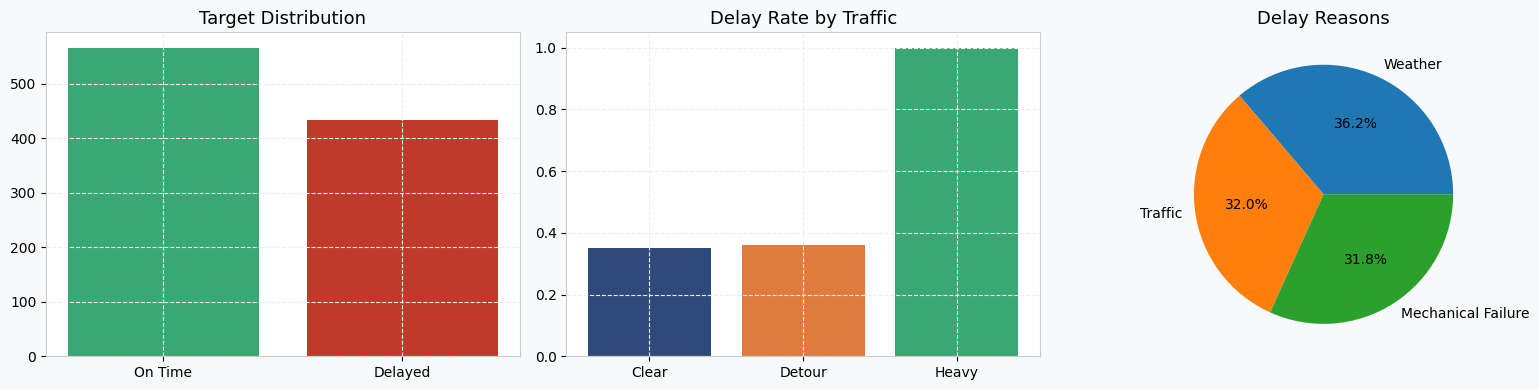

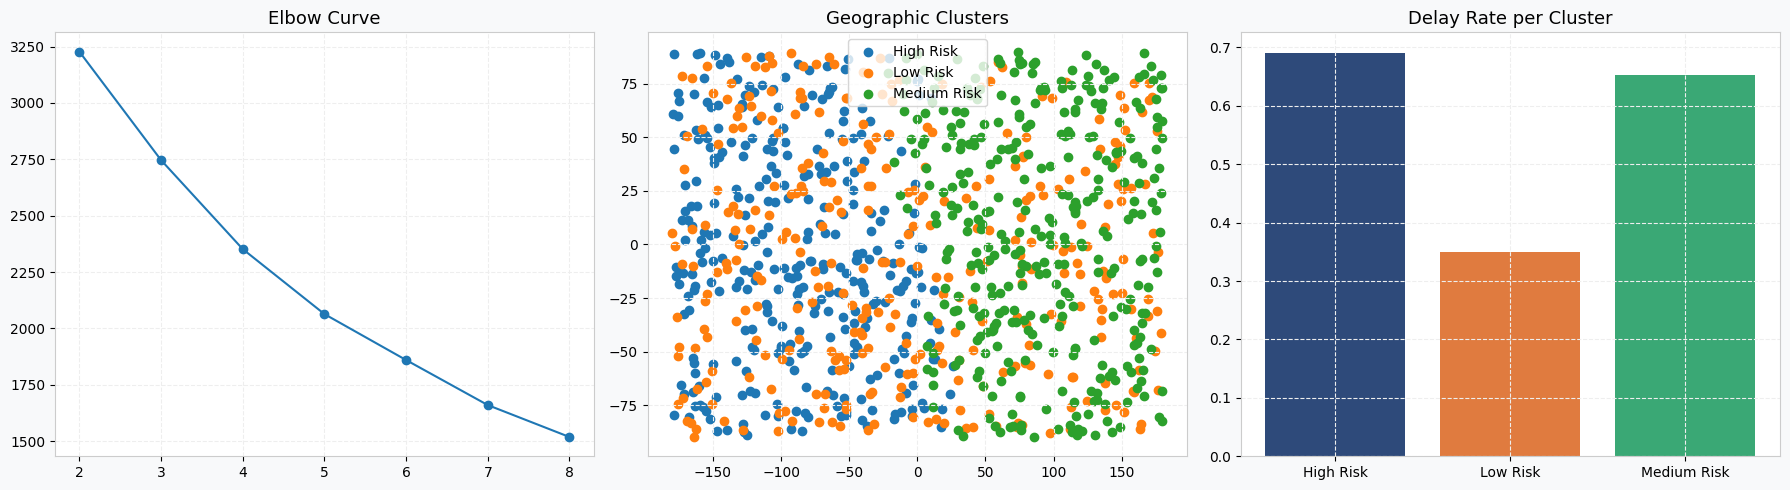

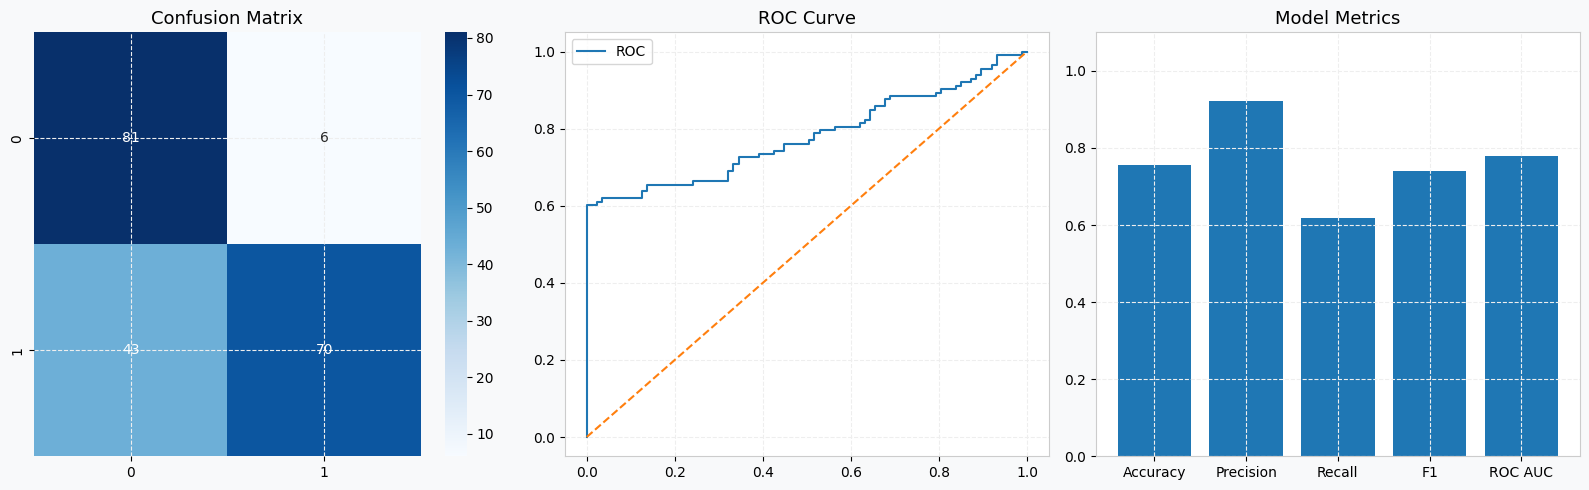

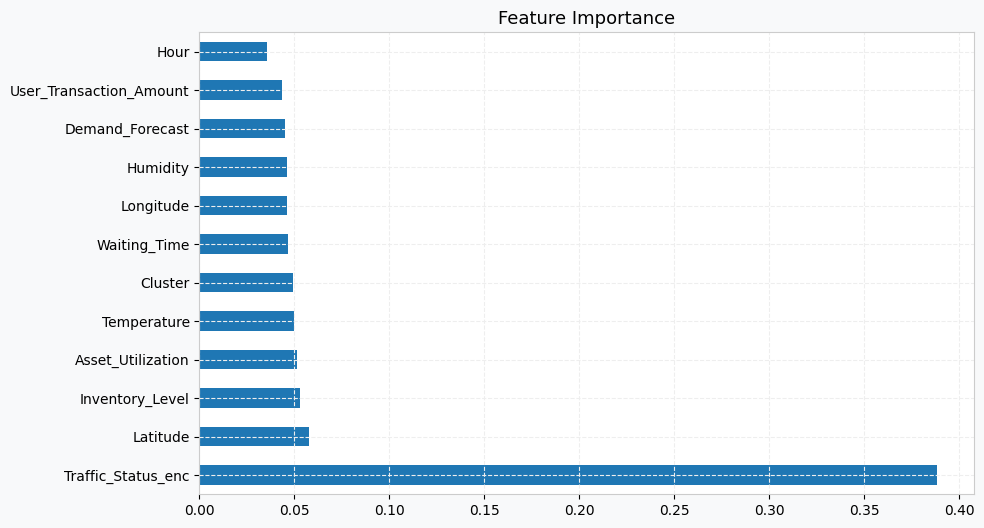

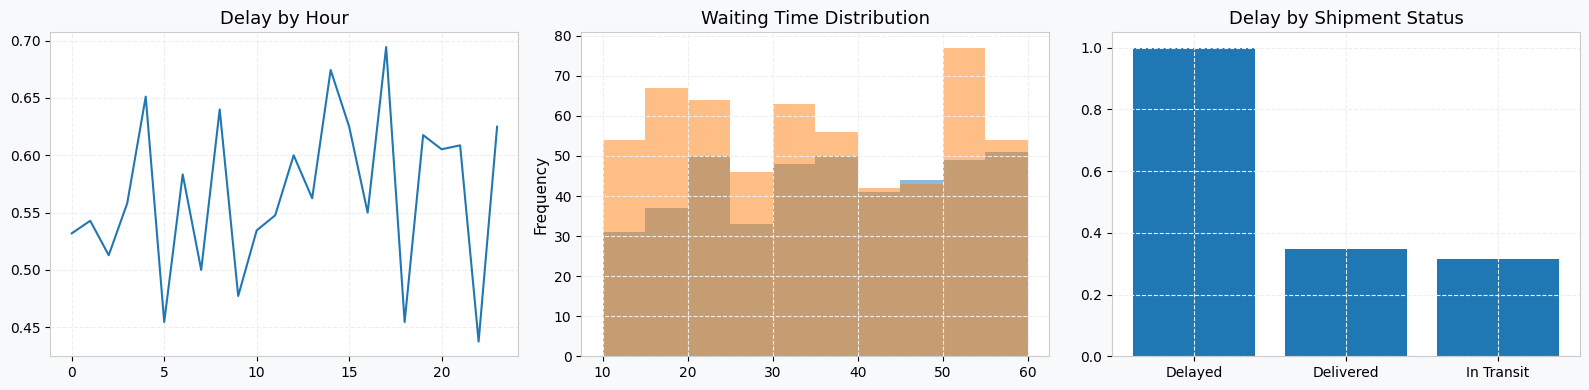

In [ ]:
# =============================================================================
# Smart Supply Chain Delay Prediction — Hybrid ML Pipeline
# Author  : Sithi J P | IPM06146
# Dataset : smart_logistics_dataset.csv
# Stages  : 1) K-Means Clustering  2) Random Forest Classification
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_curve, auc
)

# ── plotting style ─────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "#F8F9FA",
    "axes.facecolor":   "#FFFFFF",
    "axes.edgecolor":   "#CCCCCC",
    "axes.grid":        True,
    "grid.color":       "#EEEEEE",
    "grid.linestyle":   "--",
    "font.family":      "DejaVu Sans",
    "axes.titlesize":   13,
    "axes.labelsize":   11,
})

PALETTE = ["#2E4A7A", "#E07B3F", "#3AA875", "#C0392B", "#8E44AD"]

# =============================================================================
# 0. LOAD DATA
# =============================================================================

print("=" * 65)
print("SMART SUPPLY CHAIN DELAY PREDICTION — HYBRID ML PIPELINE")
print("=" * 65)

df = pd.read_csv("smart_logistics_dataset.csv")

print("\nDataset Shape:", df.shape)
print("\nTarget Distribution:\n", df["Logistics_Delay"].value_counts())

# =============================================================================
# 1. PREPROCESSING
# =============================================================================

df["Timestamp"] = pd.to_datetime(df["Timestamp"])
df["Hour"] = df["Timestamp"].dt.hour
df["Month"] = df["Timestamp"].dt.month
df["DayOfWeek"] = df["Timestamp"].dt.dayofweek

cat_cols = ["Shipment_Status", "Traffic_Status", "Logistics_Delay_Reason"]

le = LabelEncoder()
for col in cat_cols:
    df[col+"_enc"] = le.fit_transform(df[col].astype(str))

# =============================================================================
# 2. K-MEANS CLUSTERING
# =============================================================================

cluster_features = ["Latitude","Longitude","Traffic_Status_enc","Waiting_Time"]

X_cluster = df[cluster_features]

scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

inertias = []
K_range = range(2,9)

for k in K_range:
    km = KMeans(n_clusters=k,random_state=42,n_init=10)
    km.fit(X_cluster_scaled)
    inertias.append(km.inertia_)

kmeans = KMeans(n_clusters=3,random_state=42,n_init=10)

df["Cluster"] = kmeans.fit_predict(X_cluster_scaled)

delay_by_cluster = df.groupby("Cluster")["Logistics_Delay"].mean().sort_values()

cluster_labels = {
delay_by_cluster.index[0]:"Low Risk",
delay_by_cluster.index[1]:"Medium Risk",
delay_by_cluster.index[2]:"High Risk"
}

df["Cluster_Label"] = df["Cluster"].map(cluster_labels)

# =============================================================================
# 3. RANDOM FOREST CLASSIFICATION
# =============================================================================

feature_cols = [
"Latitude","Longitude","Inventory_Level","Temperature","Humidity",
"Traffic_Status_enc","Waiting_Time","User_Transaction_Amount",
"User_Purchase_Frequency","Logistics_Delay_Reason_enc",
"Asset_Utilization","Demand_Forecast","Hour","Month","DayOfWeek",
"Cluster"
]

X = df[feature_cols]
y = df["Logistics_Delay"]

X_train,X_test,y_train,y_test = train_test_split(
X,y,test_size=0.2,random_state=42,stratify=y)

scaler_rf = StandardScaler()

X_train_s = scaler_rf.fit_transform(X_train)
X_test_s = scaler_rf.transform(X_test)

rf = RandomForestClassifier(
n_estimators=200,
max_depth=12,
min_samples_split=5,
min_samples_leaf=2,
class_weight="balanced",
random_state=42,
n_jobs=-1
)

rf.fit(X_train_s,y_train)

y_pred = rf.predict(X_test_s)
y_prob = rf.predict_proba(X_test_s)[:,1]

# =============================================================================
# 4. EVALUATION
# =============================================================================

acc = accuracy_score(y_test,y_pred)
prec = precision_score(y_test,y_pred)
rec = recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)

fpr,tpr,_ = roc_curve(y_test,y_prob)
roc_auc = auc(fpr,tpr)

print("\nAccuracy:",acc)
print("Precision:",prec)
print("Recall:",rec)
print("F1 Score:",f1)
print("ROC AUC:",roc_auc)

print("\nClassification Report\n")
print(classification_report(y_test,y_pred))

feat_imp = pd.Series(rf.feature_importances_,index=feature_cols).sort_values(ascending=False)

# =============================================================================
# FIGURE 1 DATA OVERVIEW
# =============================================================================

fig,axes = plt.subplots(1,3,figsize=(16,4))

counts = y.value_counts()

axes[0].bar(["On Time","Delayed"],counts.values,color=[PALETTE[2],PALETTE[3]])
axes[0].set_title("Target Distribution")

traffic_delay = df.groupby("Traffic_Status")["Logistics_Delay"].mean()

axes[1].bar(traffic_delay.index,traffic_delay.values,color=PALETTE)
axes[1].set_title("Delay Rate by Traffic")

reason_counts = df["Logistics_Delay_Reason"].value_counts()

axes[2].pie(reason_counts.values,labels=reason_counts.index,autopct="%1.1f%%")

axes[2].set_title("Delay Reasons")

plt.tight_layout()
plt.show()

# =============================================================================
# FIGURE 2 KMEANS
# =============================================================================

fig,axes = plt.subplots(1,3,figsize=(18,5))

axes[0].plot(K_range,inertias,"o-")
axes[0].set_title("Elbow Curve")

for label,grp in df.groupby("Cluster_Label"):
    axes[1].scatter(grp["Longitude"],grp["Latitude"],label=label)

axes[1].legend()
axes[1].set_title("Geographic Clusters")

cluster_delay = df.groupby("Cluster_Label")["Logistics_Delay"].mean()

axes[2].bar(cluster_delay.index,cluster_delay.values,color=PALETTE[:3])
axes[2].set_title("Delay Rate per Cluster")

plt.tight_layout()
plt.show()

# =============================================================================
# FIGURE 3 MODEL PERFORMANCE
# =============================================================================

fig = plt.figure(figsize=(16,5))
gs = gridspec.GridSpec(1,3,figure=fig)

ax1 = fig.add_subplot(gs[0])

cm = confusion_matrix(y_test,y_pred)

sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",ax=ax1)

ax1.set_title("Confusion Matrix")

ax2 = fig.add_subplot(gs[1])

ax2.plot(fpr,tpr,label="ROC")
ax2.plot([0,1],[0,1],"--")
ax2.legend()

ax2.set_title("ROC Curve")

ax3 = fig.add_subplot(gs[2])

metrics = {"Accuracy":acc,"Precision":prec,"Recall":rec,"F1":f1,"ROC AUC":roc_auc}

ax3.bar(metrics.keys(),metrics.values())

ax3.set_ylim(0,1.1)

ax3.set_title("Model Metrics")

plt.tight_layout()
plt.show()

# =============================================================================
# FIGURE 4 FEATURE IMPORTANCE
# =============================================================================

plt.figure(figsize=(10,6))

feat_imp.head(12).plot(kind="barh")

plt.title("Feature Importance")

plt.show()

# =============================================================================
# FIGURE 5 DELAY PATTERNS
# =============================================================================

fig,axes = plt.subplots(1,3,figsize=(16,4))

hour_delay = df.groupby("Hour")["Logistics_Delay"].mean()

axes[0].plot(hour_delay.index,hour_delay.values)
axes[0].set_title("Delay by Hour")

df[df["Logistics_Delay"]==0]["Waiting_Time"].plot(kind="hist",ax=axes[1],alpha=0.5)
df[df["Logistics_Delay"]==1]["Waiting_Time"].plot(kind="hist",ax=axes[1],alpha=0.5)

axes[1].set_title("Waiting Time Distribution")

status_delay = df.groupby("Shipment_Status")["Logistics_Delay"].mean()

axes[2].bar(status_delay.index,status_delay.values)

axes[2].set_title("Delay by Shipment Status")

plt.tight_layout()
plt.show()